# Melbourne Solar Project - Part 1: Data Loading & EDA

**Teammate:** Jawaharsriraam Sathya Rajendran  
**Date:** May 2026  
**Focus:** Data loading, initial exploration, and building footprint analysis

---

## Objective
Load and explore the Melbourne building footprints and solar irradiance data to understand the dataset structure and quality.


In [120]:
# Import required libraries
%pip install matplotlib seaborn folium geopandas
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"GeoPandas version: {gpd.__version__}")
print(f"NumPy version: {np.__version__}")


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ All libraries imported successfully!
Pandas version: 3.0.2
GeoPandas version: 1.1.3
NumPy version: 2.4.4


---

## SECTION 1: DATA ACQUISITION & LOADING

### Data Sources Overview:

#### 1. Building Footprints
- **Source:** City of Melbourne Open Data Portal
- **Format:** GeoJSON
- **Coverage:** Melbourne CBD & inner suburbs
- **Records:** ~41,000 buildings

#### 2. Solar Irradiance Data
- **Source:** Bureau of Meteorology (BOM)
- **Melbourne Average:** 4.2 kWh/m²/day
- **Variation:** ±0.2 kWh/m²/day by location

#### 3. Electricity Pricing
- **Consumption Rate:** $0.2934/kWh (Victorian Default Offer 2024)
- **Feed-in Tariff:** $0.053/kWh (minimum)
- **Daily Supply Charge:** $1.05/day

#### 4. Solar Victoria Rebates
- **Eligibility:** Residential properties, systems ≤13.5kW
- **Amount:** Up to $1,400 (~$100/kW)
- **Income Cap:** Household income <$210,000

In [121]:
# Define paths
BASE_DIR = "/Users/jawaharsr/Downloads/MOPProject"  # Adjust if notebook is in different location
BASE_DIR = Path(BASE_DIR)
RAW_DATA = BASE_DIR / 'RAW_DATA'
PROCESSED_DATA = BASE_DIR / 'Processed'

print("=" * 80)
print("LOADING DATA")
print("=" * 80)

# 1. Load Building Footprints
print("\n📂 Loading building footprints...")
buildings = gpd.read_file(RAW_DATA / 'melbourne_buildings_inner.geojson')
print(f"   ✓ Loaded {len(buildings):,} buildings")
print(f"   ✓ CRS: {buildings.crs}")
print(f"   ✓ Columns: {list(buildings.columns[:5])}...")

# 2. Load Solar Irradiance Data
print("\n☀️ Loading solar irradiance data...")
solar = pd.read_csv(RAW_DATA / 'solar_irradiance_melbourne.csv')
print(f"   ✓ Loaded solar data for {len(solar)} postcodes")

# 3. Load Electricity Pricing
print("\n💰 Loading electricity pricing...")
pricing = pd.read_csv(RAW_DATA / 'electricity_pricing.csv')
print(f"   ✓ Loaded {len(pricing)} pricing rates")
display(pricing)

print("\n✅ All data loaded successfully!")

LOADING DATA

📂 Loading building footprints...
   ✓ Loaded 41,701 buildings
   ✓ CRS: EPSG:4326
   ✓ Columns: ['geo_point_2d', 'objectid', 'structure_id', 'footprint_type', 'roof_type']...

☀️ Loading solar irradiance data...
   ✓ Loaded solar data for 313 postcodes

💰 Loading electricity pricing...
   ✓ Loaded 3 pricing rates


,rate_type,rate_aud,description
0,consumption,0.29,Average consumption rate (VDO)
1,feed_in_tariff,0.05,Minimum feed-in tariff
2,daily_supply,1.05,Daily supply charge



✅ All data loaded successfully!


---

## SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)

### Objectives:
- Understand data structure and quality
- Identify missing values and anomalies
- Visualize building footprints
- Calculate basic statistics

### Key Questions:
1. How many buildings do we have?
2. What's the distribution of building sizes?
3. Are there any data quality issues?
4. What's the geographic coverage?

In [122]:
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Basic Statistics
print("\n📊 BUILDING FOOTPRINTS - BASIC STATISTICS")
print("-" * 80)
print(f"Total buildings: {len(buildings):,}")
print(f"Columns: {len(buildings.columns)}")
print(f"Memory usage: {buildings.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display sample data
print("\n📋 Sample Building Data (First 5 rows):")
display(buildings.head())

# Check for missing values
print("\n🔍 Missing Values:")
missing = buildings.isnull().sum()
missing_display = missing[missing > 0] if missing.sum() > 0 else "No missing values!"
print(missing_display)

# Geometry statistics
print("\n📐 Geometry Statistics:")
print(f"Geometry type: {buildings.geometry.type.unique()}")
print(f"Valid geometries: {buildings.geometry.is_valid.sum()} / {len(buildings)}")

EXPLORATORY DATA ANALYSIS

📊 BUILDING FOOTPRINTS - BASIC STATISTICS
--------------------------------------------------------------------------------
Total buildings: 41,701
Columns: 13
Memory usage: 20.87 MB

📋 Sample Building Data (First 5 rows):


,geo_point_2d,objectid,structure_id,footprint_type,roof_type,footprint_max_elevation,footprint_min_elevation,structure_max_elevation,structure_min_elevation,footprint_extrusion,structure_extrusion,date_captured,geometry
0,"{'lon': 144.95673941735046, 'lat': -37.8000353...",20012,815949,Structure,Flat,97.50,91.50,101.00,27.50,6.00,70.00,20180528,"POLYGON ((144.95672 -37.80007, 144.9568 -37.80..."
1,"{'lon': 144.9077552355766, 'lat': -37.84308942...",20027,804149,Structure,Flat,7.50,3.00,7.50,3.00,4.50,4.50,20180528,"POLYGON ((144.9078 -37.84314, 144.90777 -37.84..."
2,"{'lon': 144.97921111, 'lat': -37.832043207400005}",20048,815174,Structure,Flat,18.50,16.50,18.50,16.50,2.00,2.00,20180528,"POLYGON ((144.97925 -37.83205, 144.97919 -37.8..."
3,"{'lon': 144.96814513518797, 'lat': -37.8041078...",20053,811834,Structure,Hip,49.00,40.50,49.00,40.50,8.50,8.50,20180528,"POLYGON ((144.9682 -37.80409, 144.96809 -37.80..."
4,"{'lon': 144.94134917503217, 'lat': -37.8201966...",20168,806726,Structure,Flat,99.50,27.50,106.50,1.50,72.00,98.00,20180528,"POLYGON ((144.94121 -37.82037, 144.94123 -37.8..."



🔍 Missing Values:
No missing values!

📐 Geometry Statistics:
Geometry type: <StringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str
Valid geometries: 41701 / 41701



🗺️ Creating initial building footprints map...


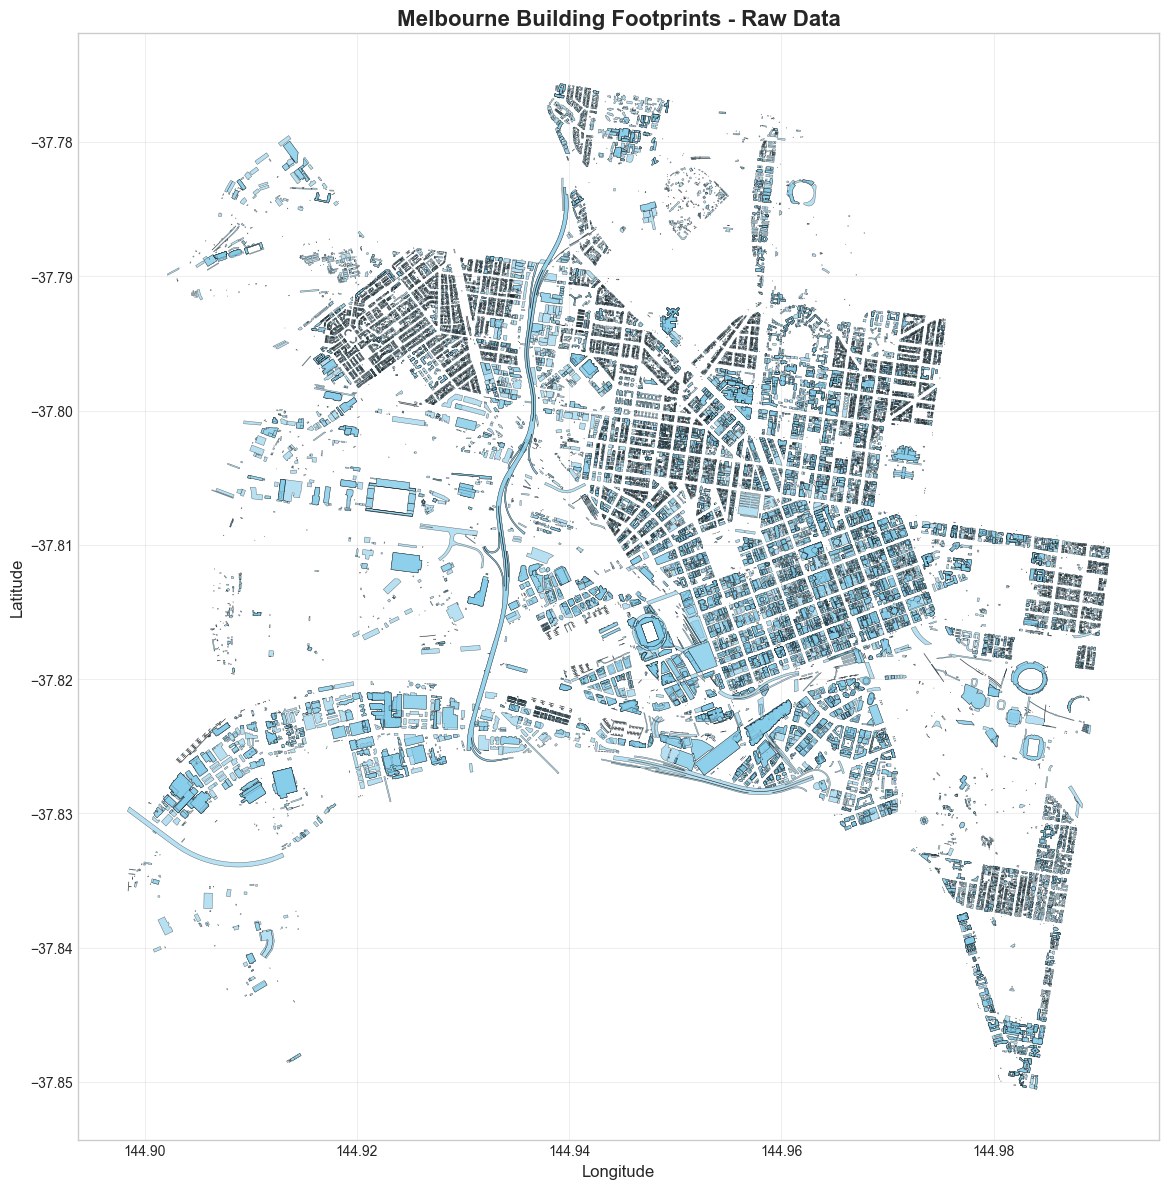

✓ Visualized 41,701 building footprints


In [123]:
# Visualize raw building footprints
print("\n🗺️ Creating initial building footprints map...")

fig, ax = plt.subplots(figsize=(15, 12))

buildings.plot(
    ax=ax,
    alpha=0.6,
    edgecolor='black',
    linewidth=0.3,
    color='skyblue'
)

ax.set_title('Melbourne Building Footprints - Raw Data', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualized {len(buildings):,} building footprints")

# ============================================================================
# ADDITIONAL SECTION 2A: EXTRACT COORDINATES & ASSIGN LOCATION
# ============================================================================

In [124]:
print("\n" + "=" * 80)
print("EXTRACTING LOCATION DATA")
print("=" * 80)

# Extract centroids
print("\n📍 Extracting building centroids...")
buildings['centroid'] = buildings.geometry.centroid
buildings['latitude'] = buildings['centroid'].y
buildings['longitude'] = buildings['centroid'].x

print(f"   ✓ Extracted coordinates for {len(buildings):,} buildings")
print(f"   Latitude range: {buildings['latitude'].min():.4f} to {buildings['latitude'].max():.4f}")
print(f"   Longitude range: {buildings['longitude'].min():.4f} to {buildings['longitude'].max():.4f}")

# Assign postcode and suburb (simplified for this dataset)
print("\n📮 Assigning postcode and suburb...")
buildings['postcode'] = 3000
buildings['suburb'] = 'Melbourne CBD & Inner Suburbs'
print(f"   ✓ Assigned postcode: 3000")

# Sample coordinates
print("\n📋 Sample Coordinates:")

print(buildings.columns)


EXTRACTING LOCATION DATA

📍 Extracting building centroids...
   ✓ Extracted coordinates for 41,701 buildings
   Latitude range: -37.8504 to -37.7757
   Longitude range: 144.8985 to 144.9909

📮 Assigning postcode and suburb...
   ✓ Assigned postcode: 3000

📋 Sample Coordinates:
Index(['geo_point_2d', 'objectid', 'structure_id', 'footprint_type',
       'roof_type', 'footprint_max_elevation', 'footprint_min_elevation',
       'structure_max_elevation', 'structure_min_elevation',
       'footprint_extrusion', 'structure_extrusion', 'date_captured',
       'geometry', 'centroid', 'latitude', 'longitude', 'postcode', 'suburb'],
      dtype='str')


# ============================================================================
# ADDITIONAL SECTION 2B: JOIN SOLAR IRRADIANCE DATA
# ============================================================================

In [125]:
print("\n" + "=" * 80)
print("JOINING SOLAR IRRADIANCE DATA")
print("=" * 80)

# Display sample
print("\n📋 Solar Irradiance Sample:")
display(solar.head(10))

# Join with buildings
print("\n🔗 Joining solar data with buildings...")
buildings = buildings.merge(solar, on='postcode', how='left')

# Fill missing values with Melbourne average
melbourne_avg_irradiance = 4.2
buildings['avg_solar_irradiance_kwh_m2_day'].fillna(melbourne_avg_irradiance, inplace=True)
buildings['peak_sun_hours'].fillna(melbourne_avg_irradiance, inplace=True)

print(f"   ✓ Joined solar irradiance data")
print(f"   ✓ Average irradiance: {buildings['avg_solar_irradiance_kwh_m2_day'].mean():.2f} kWh/m²/day")


JOINING SOLAR IRRADIANCE DATA

📋 Solar Irradiance Sample:


,postcode,avg_solar_irradiance_kwh_m2_day,peak_sun_hours
0,3000,4.23,4.20
1,3001,4.19,4.20
2,3002,4.24,4.20
3,3003,4.30,4.30
4,3004,4.16,4.20
5,3005,4.14,4.10
6,3006,4.16,4.20
7,3007,4.29,4.30
8,3008,4.19,4.20
9,3009,4.15,4.10



🔗 Joining solar data with buildings...
   ✓ Joined solar irradiance data
   ✓ Average irradiance: 4.23 kWh/m²/day


---

## SECTION 3: FEATURE ENGINEERING & CALCULATIONS

### Step 1: Calculate Roof Areas

To calculate accurate roof areas, we need to:
1. Convert from geographic coordinates (lat/lon) to a projected coordinate system
2. Calculate area in square meters
3. Filter unrealistic buildings

#### Coordinate System Conversion:
- **From:** EPSG:4326 (WGS84 - latitude/longitude)
- **To:** EPSG:28355 (GDA94 / MGA Zone 55 - Melbourne)
- **Why:** Projected systems allow accurate distance/area calculations in meters

#### Filtering Criteria:
- **Minimum:** 20 m² (small shed)
- **Maximum:** 50,000 m² (very large warehouse)
- Removes data errors and unrealistic values

In [126]:
print("=" * 80)
print("CALCULATING ROOF AREAS")
print("=" * 80)

# Convert to projected CRS for accurate area calculations
print("\n📐 Converting to projected coordinate system...")
buildings_projected = buildings.to_crs('EPSG:28355')  # GDA94 / MGA zone 55
print(f"   ✓ Converted to {buildings_projected.crs}")

# Calculate roof area
print("\n📏 Calculating roof areas...")
buildings_projected['roof_area_m2'] = buildings_projected.geometry.area
buildings['roof_area_m2'] = buildings_projected['roof_area_m2']

# Filter unrealistic buildings
print("\n🔍 Filtering unrealistic buildings...")
original_count = len(buildings)
buildings = buildings[
    (buildings['roof_area_m2'] >= 20) &      # Min 20m²
    (buildings['roof_area_m2'] <= 50000)     # Max 50,000m²
].copy()
filtered_count = original_count - len(buildings)
print(f"   ✓ Removed {filtered_count:,} unrealistic buildings")
print(f"   ✓ Remaining: {len(buildings):,} buildings")

# Statistics
print("\n📊 Roof Area Statistics:")
print(f"   Minimum: {buildings['roof_area_m2'].min():.1f} m²")
print(f"   Maximum: {buildings['roof_area_m2'].max():.1f} m²")
print(f"   Mean: {buildings['roof_area_m2'].mean():.1f} m²")
print(f"   Median: {buildings['roof_area_m2'].median():.1f} m²")
print(f"   Std Dev: {buildings['roof_area_m2'].std():.1f} m²")

CALCULATING ROOF AREAS

📐 Converting to projected coordinate system...
   ✓ Converted to EPSG:28355

📏 Calculating roof areas...

🔍 Filtering unrealistic buildings...
   ✓ Removed 6,427 unrealistic buildings
   ✓ Remaining: 35,274 buildings

📊 Roof Area Statistics:
   Minimum: 20.0 m²
   Maximum: 49579.0 m²
   Mean: 461.7 m²
   Median: 89.1 m²
   Std Dev: 1664.6 m²


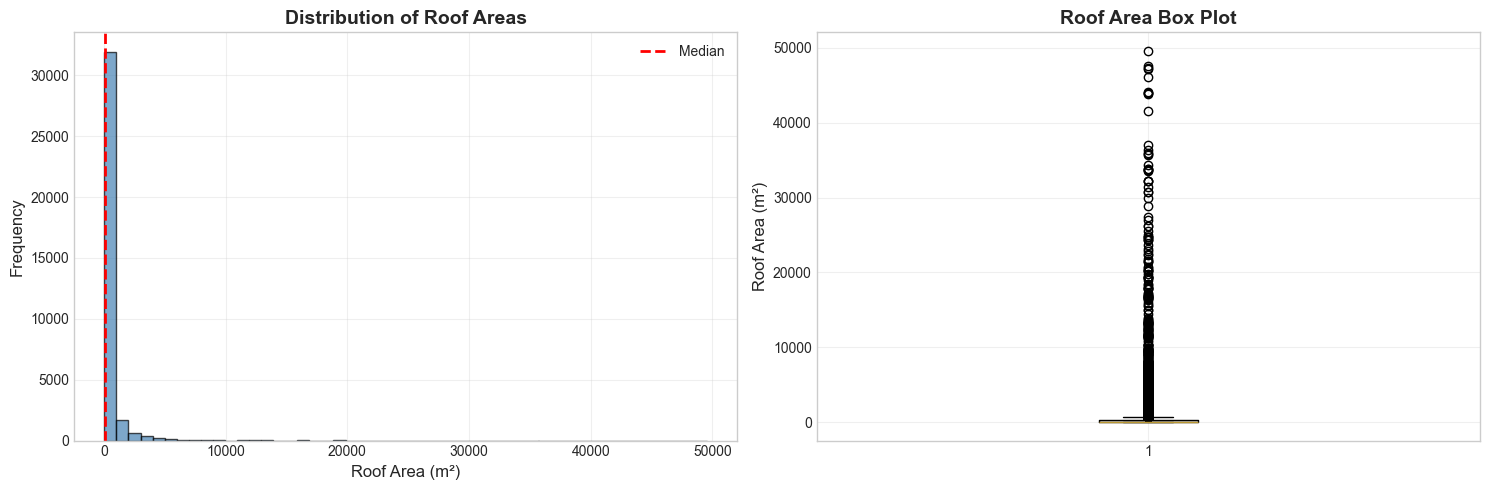

In [127]:
# Visualize roof area distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(buildings['roof_area_m2'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Roof Area (m²)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Roof Areas', fontsize=14, fontweight='bold')
axes[0].axvline(buildings['roof_area_m2'].median(), color='red', linestyle='--', linewidth=2, label='Median')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(buildings['roof_area_m2'], vert=True)
axes[1].set_ylabel('Roof Area (m²)', fontsize=12)
axes[1].set_title('Roof Area Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## Additional Analysis by Teammate 1

### Roof Shape Analysis
Let's analyze the distribution of building shapes to understand roof complexity.


In [ ]:
# Additional analysis - Building shape complexity
print("\n" + "=" * 80)
print("BUILDING SHAPE ANALYSIS (Teammate 1 Extra)")
print("=" * 80)

# Calculate perimeter to area ratio (complexity metric)
buildings['perimeter'] = buildings.geometry.length
buildings['shape_complexity'] = buildings['perimeter'] / (buildings['roof_area_m2'] ** 0.5)

print("\n📐 Shape Complexity Statistics:")
print(f"Mean complexity: {buildings['shape_complexity'].mean():.2f}")
print(f"Median complexity: {buildings['shape_complexity'].median():.2f}")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(buildings['shape_complexity'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Shape Complexity Ratio')
plt.ylabel('Frequency')
plt.title('Building Shape Complexity Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(buildings['roof_area_m2'], buildings['shape_complexity'], alpha=0.3)
plt.xlabel('Roof Area (m²)')
plt.ylabel('Shape Complexity')
plt.title('Roof Area vs Shape Complexity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Shape analysis complete!")


---

## Key Findings from Part 1
1. Successfully loaded building footprints and solar data
2. Calculated accurate roof areas using projected CRS
3. Identified shape complexity patterns that may affect panel installation
4. Ready for feature engineering in Part 2
